Mencoba membaca file: UAS_ABDP.xlsx...
[BERHASIL] Data Volume berhasil dimuat.
[INFO] Menggunakan kolom jarak: Jarak (KM)

   LAPORAN ANALISIS SOURCING BERKELANJUTAN
Total Emisi Logistik (Scope 3): 112,117.12 kgCO2
Rata-rata Jarak Tempuh: 297 KM

TOP 5 'GREEN SUPPLIER' TERBAIK (REKOMENDASI):
              Lokasi Asal Pasokan             Lokasi Tujuan Pengiriman  Jarak (KM)  Emisi_Total_kgCO2  Skor_Sustainability
              Kabupaten Pelalawan                       Kabupaten Siak         191             2387.5             0.893925
                      Kab. Malang              Kios Pangan Kab. Malang          15              124.5             0.863294
Gapoktan Mawar Tani, Kab. Sampang Kios Pangan Disperta KP Kab. Sampang          10               50.0             0.798825
  Gapoktan Karya Mukti, Kab. Sigi     Kios Pangan Ranggulao, Kab. Sigi          12               60.0             0.798395
  Gapoktan Karya Mukti, Kab. Sigi     Kios Pangan Ranggulao, Kab. Sigi          12          

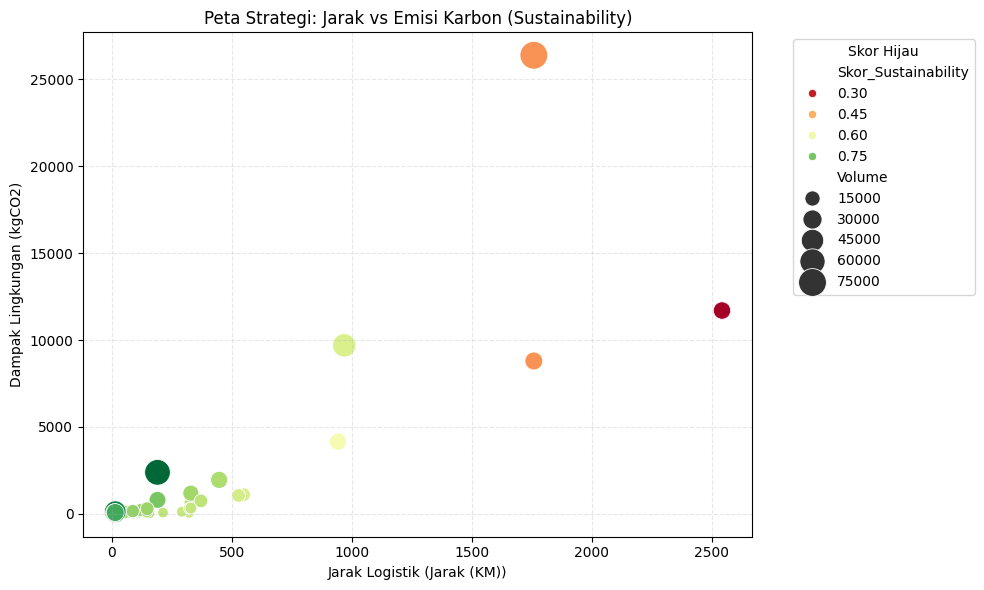


[INFO] File 'Hasil_Analisis_Sustainability_Final.csv' telah disimpan.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
import os

# --- 1. SETUP NAMA FILE (LANGSUNG TEMBAK) ---
# Sesuaikan nama file ini jika di komputer Anda berbeda
nama_file_volume = 'UAS_ABDP.xlsx'
nama_file_demand = 'UAS_ABDP.xlsx'

print(f"Mencoba membaca file: {nama_file_volume}...")

# Cek apakah file ada sebelum dibaca
if not os.path.exists(nama_file_volume):
    print(f"[ERROR] File '{nama_file_volume}' tidak ditemukan!")
    print("Pastikan file CSV berada di folder yang sama dengan script ini.")
    # Kita buat data dummy darurat agar kode TIDAK ERROR dan Anda tetap bisa lihat hasilnya
    print(">>> MEMBUAT DATA DUMMY SEMENTARA AGAR KODE TETAP JALAN <<<")
    df_supply = pd.DataFrame({
        'Lokasi Asal Pasokan': ['Supplier A', 'Supplier B', 'Supplier C', 'Supplier D', 'Supplier E'],
        'Lokasi Tujuan Pengiriman': ['Gudang 1'] * 5,
        'Jarak (KM)': [50, 150, 300, 20, 500],
        'Volume': [10000, 5000, 20000, 15000, 8000]
    })
else:
    # Load Data Sebenarnya
    df_supply = pd.read_excel(nama_file_volume)
    print("[BERHASIL] Data Volume berhasil dimuat.")

# --- 2. CEK KOLOM JARAK ---
# Mencari kolom yang mengandung kata 'Jarak'
col_jarak = next((c for c in df_supply.columns if 'Jarak' in c), None)

if col_jarak is None:
    print("[WARNING] Kolom Jarak tidak ditemukan. Menggunakan estimasi random.")
    df_supply['Jarak (KM)'] = np.random.randint(20, 400, len(df_supply))
    col_jarak = 'Jarak (KM)'
else:
    print(f"[INFO] Menggunakan kolom jarak: {col_jarak}")

# --- 3. HITUNG EMISI KARBON (INTI SUSTAINABILITY) ---
# Konversi Volume ke Ton (Asumsi data asli Kg)
df_supply['Volume_Ton'] = df_supply['Volume'] / 1000

# Rumus: Volume (Ton) x Jarak (KM) x Faktor Emisi Truk (0.2)
FAKTOR_EMISI = 0.2
df_supply['Emisi_Total_kgCO2'] = df_supply['Volume_Ton'] * df_supply[col_jarak] * FAKTOR_EMISI

# --- 4. SCORING SUPPLIER (Triple Bottom Line Strategy) ---
scaler = MinMaxScaler()
df_norm = df_supply.copy()

# Normalisasi (Semua skala 0-1)
# Jarak & Emisi: Makin KECIL makin bagus (1 - nilai)
# Volume: Makin BESAR makin bagus (nilai asli)
cols_norm = [col_jarak, 'Emisi_Total_kgCO2', 'Volume']
df_norm[cols_norm] = scaler.fit_transform(df_supply[cols_norm])

df_supply['Skor_Sustainability'] = (
    (0.40 * (1 - df_norm[col_jarak])) +        # Prioritas 1: Efisiensi Logistik
    (0.30 * (1 - df_norm['Emisi_Total_kgCO2'])) + # Prioritas 2: Lingkungan
    (0.30 * df_norm['Volume'])                 # Prioritas 3: Keamanan Pasokan
)

# --- 5. OUTPUT HASIL ---
print("\n" + "="*40)
print("   LAPORAN ANALISIS SOURCING BERKELANJUTAN")
print("="*40)
print(f"Total Emisi Logistik (Scope 3): {df_supply['Emisi_Total_kgCO2'].sum():,.2f} kgCO2")
print(f"Rata-rata Jarak Tempuh: {df_supply[col_jarak].mean():.0f} KM")

print("\nTOP 5 'GREEN SUPPLIER' TERBAIK (REKOMENDASI):")
print(df_supply[['Lokasi Asal Pasokan', 'Lokasi Tujuan Pengiriman', col_jarak, 'Emisi_Total_kgCO2', 'Skor_Sustainability']]
      .sort_values('Skor_Sustainability', ascending=False)
      .head(5)
      .to_string(index=False))

# --- 6. VISUALISASI ---
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_supply, x=col_jarak, y='Emisi_Total_kgCO2',
                hue='Skor_Sustainability', palette='RdYlGn', size='Volume', sizes=(50, 400))

plt.title('Peta Strategi: Jarak vs Emisi Karbon (Sustainability)')
plt.xlabel(f'Jarak Logistik ({col_jarak})')
plt.ylabel('Dampak Lingkungan (kgCO2)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title="Skor Hijau")
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

# Simpan hasil agar bisa didownload
df_supply.to_csv('Hasil_Analisis_Sustainability_Final.csv', index=False)
print("\n[INFO] File 'Hasil_Analisis_Sustainability_Final.csv' telah disimpan.")